In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/LIDR-IDRI/LIDC-IDRI-slices"



In [ ]:
import os
print(os.listdir(dataset_path)[:5])


['LIDC-IDRI-1012', 'LIDC-IDRI-1010', 'LIDC-IDRI-1011', 'LIDC-IDRI-1009', 'LIDC-IDRI-1007']


In [ ]:
!pip install pydicom
!pip install scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
def load_nodule(nodule_path):
    image_folder = os.path.join(nodule_path, "images")
    mask_folders = [os.path.join(nodule_path, m)
                    for m in os.listdir(nodule_path) if "mask" in m]

    images = []
    masks = []

    image_files = sorted(os.listdir(image_folder))

    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        images.append(img)

        combined_mask = np.zeros_like(img)

        for mask_folder in mask_folders:
            mask_path = os.path.join(mask_folder, img_file)
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                combined_mask = np.maximum(combined_mask, mask)

        masks.append(combined_mask)

    return np.array(images), np.array(masks)


In [ ]:
def normalize_images(images):
    images = images.astype(np.float32) / 255.0
    return images


In [ ]:
def resize_images(images, masks, size=(128,128)):
    resized_images = []
    resized_masks = []

    for img, mask in zip(images, masks):
        img_resized = cv2.resize(img, size)
        mask_resized = cv2.resize(mask, size)

        resized_images.append(img_resized)
        resized_masks.append(mask_resized)

    return np.array(resized_images), np.array(resized_masks)


In [ ]:
patient = "LIDC-IDRI-0001"
nodule = "nodule-0"

nodule_path = os.path.join(dataset_path, patient, nodule)

images, masks = load_nodule(nodule_path)
images = normalize_images(images)
images, masks = resize_images(images, masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)


Images shape: (9, 128, 128)
Masks shape: (9, 128, 128)


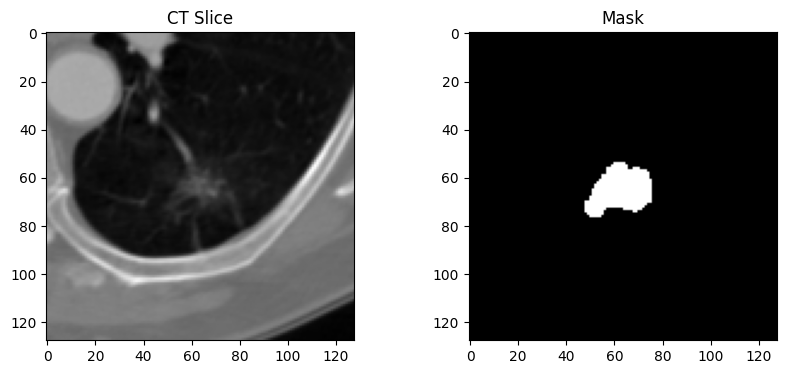

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(images[0], cmap='gray')
plt.title("CT Slice")

plt.subplot(1,2,2)
plt.imshow(masks[0], cmap='gray')
plt.title("Mask")

plt.show()


In [ ]:
total_patients = os.listdir(dataset_path)
total_nodules = 0

for patient in total_patients:
    patient_path = os.path.join(dataset_path, patient)
    nodules = os.listdir(patient_path)
    total_nodules += len(nodules)

print("Total Patients:", len(total_patients))
print("Total Nodules:", total_nodules)

Total Patients: 875
Total Nodules: 2631


## EDA


In [ ]:
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/LIDR-IDRI/LIDC-IDRI-slices"

patients = os.listdir(dataset_path)

total_patients = 0
total_nodules = 0
total_slices = 0
slice_counts = []

for patient in patients:
    patient_path = os.path.join(dataset_path, patient)

    # Skip if not directory
    if not os.path.isdir(patient_path):
        continue

    total_patients += 1
    nodules = os.listdir(patient_path)

    for nodule in nodules:
        nodule_path = os.path.join(patient_path, nodule)

        # Skip if not directory
        if not os.path.isdir(nodule_path):
            continue

        img_folder = os.path.join(nodule_path, "images")

        # Check if images folder exists
        if not os.path.exists(img_folder):
            print(f"Skipping invalid folder: {nodule_path}")
            continue

        image_files = [f for f in os.listdir(img_folder) if f.endswith(".png")]

        if len(image_files) == 0:
            continue

        total_nodules += 1
        num_slices = len(image_files)
        slice_counts.append(num_slices)
        total_slices += num_slices

print("Total Patients:", total_patients)
print("Total Valid Nodules:", total_nodules)
print("Total Slices:", total_slices)
print("Average slices per nodule:", np.mean(slice_counts))


Skipping invalid folder: /content/drive/MyDrive/LIDR-IDRI/LIDC-IDRI-slices/LIDC-IDRI-1003/nodule-4 (1)
Total Patients: 875
Total Valid Nodules: 2630
Total Slices: 15568
Average slices per nodule: 5.919391634980989


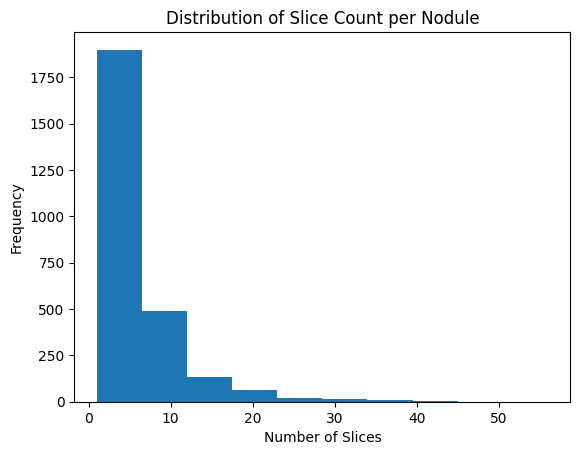

In [ ]:
import matplotlib.pyplot as plt

plt.hist(slice_counts, bins=10)
plt.title("Distribution of Slice Count per Nodule")
plt.xlabel("Number of Slices")
plt.ylabel("Frequency")
plt.show()


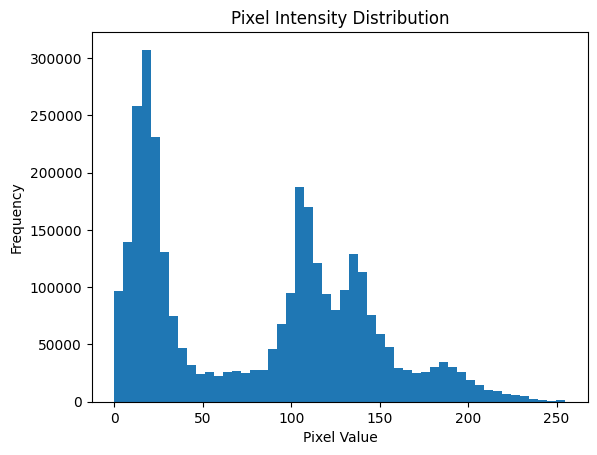

In [ ]:
import cv2
import random

all_pixels = []

# Randomly sample 50 nodules
sample_patients = random.sample(patients, min(10, len(patients)))

for patient in sample_patients:
    patient_path = os.path.join(dataset_path, patient)
    nodules = os.listdir(patient_path)

    for nodule in nodules:
        img_folder = os.path.join(patient_path, nodule, "images")
        img_files = os.listdir(img_folder)

        for img_file in img_files:
            img_path = os.path.join(img_folder, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            all_pixels.extend(img.flatten())

plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


Total Sampled Mask Samples: 95


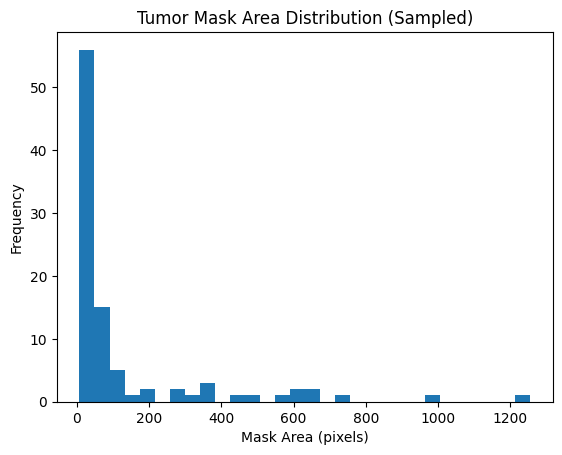

In [ ]:
import random

mask_areas = []

# Sample only 20 patients
sample_patients = random.sample(patients, min(20, len(patients)))

for patient in sample_patients:
    patient_path = os.path.join(dataset_path, patient)

    if not os.path.isdir(patient_path):
        continue

    nodules = os.listdir(patient_path)

    # Sample only 2 nodules per patient
    nodules = random.sample(nodules, min(2, len(nodules)))

    for nodule in nodules:
        nodule_path = os.path.join(patient_path, nodule)

        image_folder = os.path.join(nodule_path, "images")
        if not os.path.exists(image_folder):
            continue

        image_files = [f for f in os.listdir(image_folder) if f.endswith(".png")]
        if len(image_files) == 0:
            continue

        mask_folders = [os.path.join(nodule_path, m)
                        for m in os.listdir(nodule_path)
                        if "mask" in m and os.path.isdir(os.path.join(nodule_path, m))]

        if len(mask_folders) == 0:
            continue

        # Sample only 3 slices per nodule
        image_files = random.sample(image_files, min(3, len(image_files)))

        for img_file in image_files:
            combined_mask = None

            for mask_folder in mask_folders:
                mask_path = os.path.join(mask_folder, img_file)
                if not os.path.exists(mask_path):
                    continue

                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if mask is None:
                    continue

                if combined_mask is None:
                    combined_mask = mask
                else:
                    combined_mask = np.maximum(combined_mask, mask)

            if combined_mask is not None:
                mask_area = np.sum(combined_mask > 0)
                mask_areas.append(mask_area)

print("Total Sampled Mask Samples:", len(mask_areas))

plt.hist(mask_areas, bins=30)
plt.title("Tumor Mask Area Distribution (Sampled)")
plt.xlabel("Mask Area (pixels)")
plt.ylabel("Frequency")
plt.show()


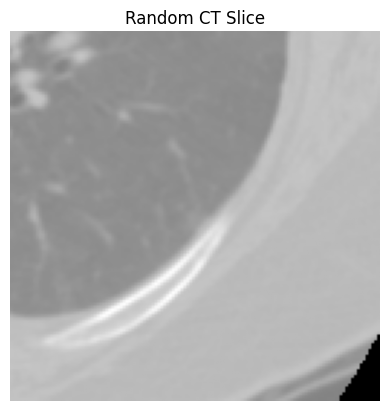

In [ ]:
patient = random.choice(patients)
patient_path = os.path.join(dataset_path, patient)
nodule = random.choice(os.listdir(patient_path))

nodule_path = os.path.join(patient_path, nodule)
img_folder = os.path.join(nodule_path, "images")
img_file = random.choice(os.listdir(img_folder))

img = cv2.imread(os.path.join(img_folder, img_file), cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Random CT Slice")
plt.axis('off')
plt.show()


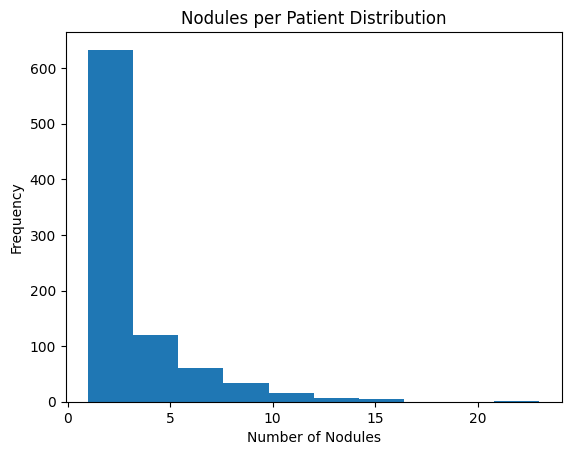

In [ ]:
nodules_per_patient = []

for patient in patients:
    patient_path = os.path.join(dataset_path, patient)
    nodules = os.listdir(patient_path)
    nodules_per_patient.append(len(nodules))

plt.hist(nodules_per_patient, bins=10)
plt.title("Nodules per Patient Distribution")
plt.xlabel("Number of Nodules")
plt.ylabel("Frequency")
plt.show()
